   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  
1  medium  
2 

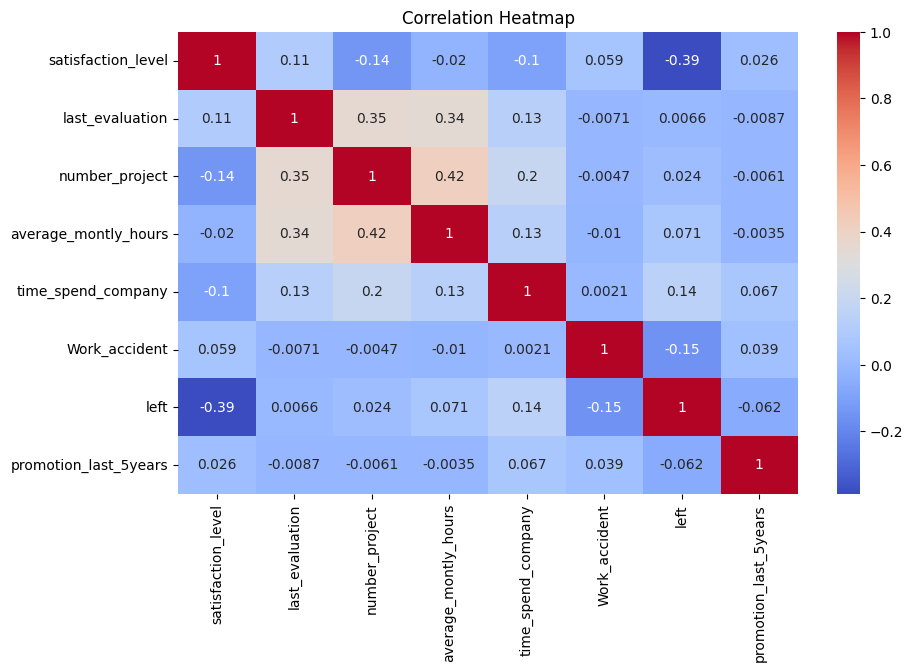

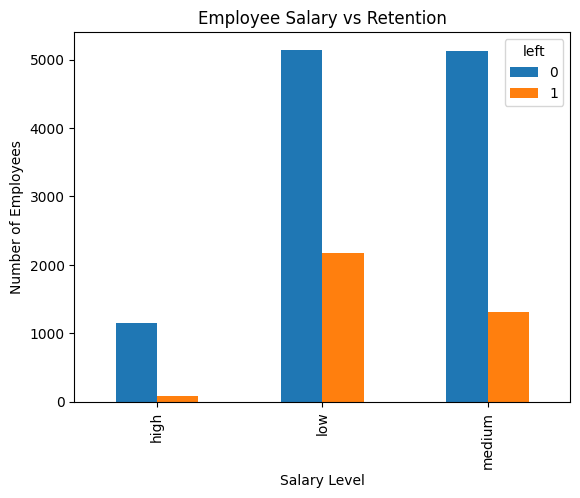

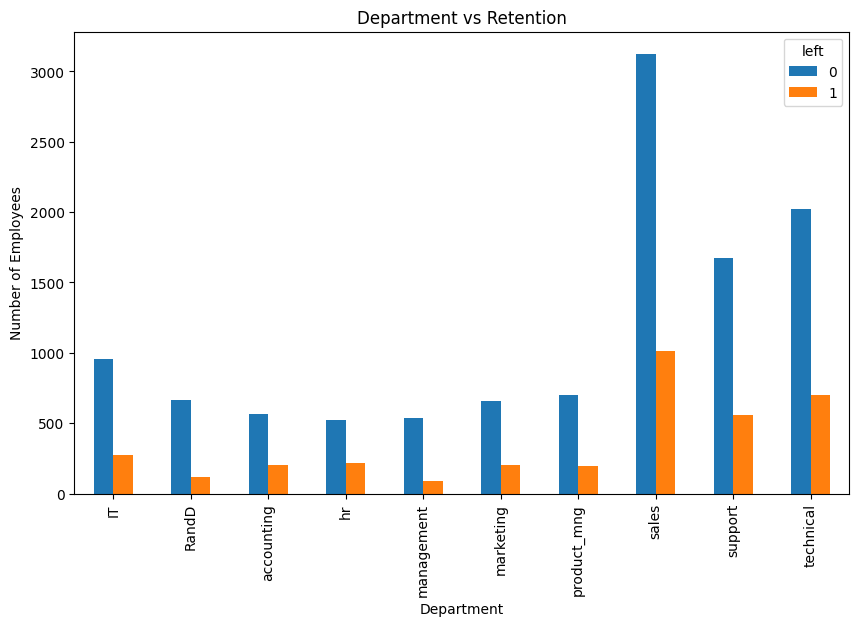

Model Accuracy: 0.7636666666666667
Confusion Matrix:
 [[2118  176]
 [ 533  173]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.92      0.86      2294
           1       0.50      0.25      0.33       706

    accuracy                           0.76      3000
   macro avg       0.65      0.58      0.59      3000
weighted avg       0.73      0.76      0.73      3000



In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("HR_comma_sep.csv")

# -------------------------------
# 1. Exploratory Data Analysis
# -------------------------------

print(df.head())
print(df.info())
print(df.describe())

# Check correlation
plt.figure(figsize=(10,6))
# Select only numeric columns for correlation calculation
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# -------------------------------
# 2. Salary vs Retention
# -------------------------------

salary_retention = pd.crosstab(df['salary'], df['left'])
salary_retention.plot(kind='bar')
plt.title("Employee Salary vs Retention")
plt.xlabel("Salary Level")
plt.ylabel("Number of Employees")
plt.show()

# -------------------------------
# 3. Department vs Retention
# -------------------------------

department_retention = pd.crosstab(df['Department'], df['left']) # Corrected 'sales' to 'Department'
department_retention.plot(kind='bar', figsize=(10,6))
plt.title("Department vs Retention")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.show()

# -------------------------------
# 4. Data Preprocessing
# -------------------------------

# Convert categorical variables to dummy variables
df = pd.get_dummies(df, columns=['salary', 'Department'], drop_first=True) # Corrected 'sales' to 'Department'

# Select important features (based on EDA)
features = [
    'satisfaction_level',
    'average_montly_hours',
    'promotion_last_5years',
    'time_spend_company',
    'Work_accident'
]

# Add encoded categorical columns
features.extend([col for col in df.columns if 'salary_' in col or 'Department_' in col]) # Corrected 'sales_' to 'Department_'

X = df[features]
y = df['left']

# -------------------------------
# 5. Train-Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------
# 6. Logistic Regression Model
# -------------------------------

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# -------------------------------
# 7. Predictions and Accuracy
# -------------------------------

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   class_type  
0           1  
1           1  
2           4  
3   

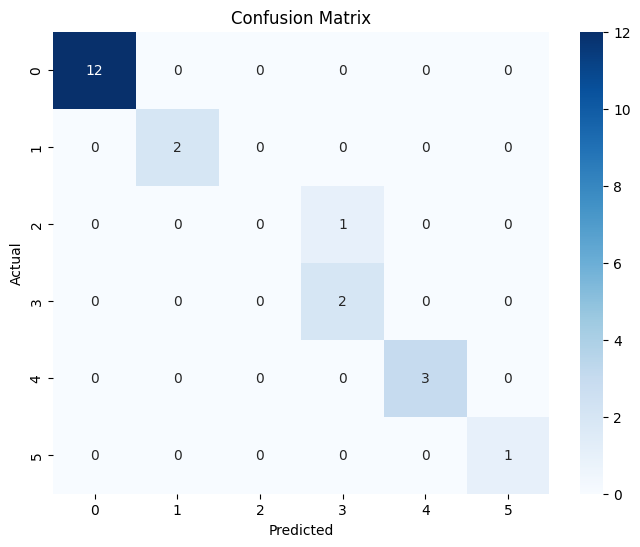

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         2
           3       0.00      0.00      0.00         1
           4       0.67      1.00      0.80         2
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         1

    accuracy                           0.95        21
   macro avg       0.78      0.83      0.80        21
weighted avg       0.92      0.95      0.93        21



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -------------------------------
# 1. Load datasets
# -------------------------------

zoo_df = pd.read_csv("/content/zoo-data.csv")
class_df = pd.read_csv("/content/zoo-class-type.csv")

# Display first few rows
print(zoo_df.head())
print(class_df.head())

# -------------------------------
# 2. Data Preprocessing
# -------------------------------

# Drop 'animal_name' as it is not useful for prediction
zoo_df = zoo_df.drop('animal_name', axis=1)

# Check for missing values
print(zoo_df.isnull().sum())

# No missing values expected, otherwise handle here

# -------------------------------
# 3. Define features and target
# -------------------------------

X = zoo_df.drop('class_type', axis=1)
y = zoo_df['class_type']

# -------------------------------
# 4. Train-Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 5. Build Logistic Regression Model
# -------------------------------

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# -------------------------------
# 6. Predictions
# -------------------------------

y_pred = model.predict(X_test)

# -------------------------------
# 7. Accuracy
# -------------------------------

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# -------------------------------
# 8. Confusion Matrix
# -------------------------------

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -------------------------------
# 9. Classification Report
# -------------------------------

print("Classification Report:\n", classification_report(y_test, y_pred))
